# Лабораторная работа №6
## Задание
Выделить на изображении что-нибудь

## Решение

In [1]:
from google.colab import drive
import sys
drive.mount('/content/drive', force_remount=True)
sys.path.append('/content/drive/MyDrive/Colab Notebooks/ЦОИ отчеты')

Mounted at /content/drive


In [2]:
import numpy as np
import cv2 as cv2
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.cluster import KMeans
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage import data
from scipy import ndimage
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import math
%matplotlib inline
import segmentation_utils

### Исходное изображение

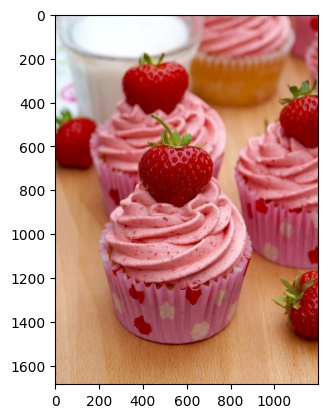

In [3]:
image_path = '/content/drive/MyDrive/Colab Notebooks/ЦОИ отчеты/lab5.jpg'
img = cv2.imread(image_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

In [4]:
image_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

### Метод разрастания регионов


/content/drive/MyDrive/Colab Notebooks/ЦОИ отчеты/segmentation_utils.py:41: RuntimeWarning: overflow encountered in scalar add
  similarity = sum(abs(image[x, y, :] - image[seed_x, seed_y, :]))/3


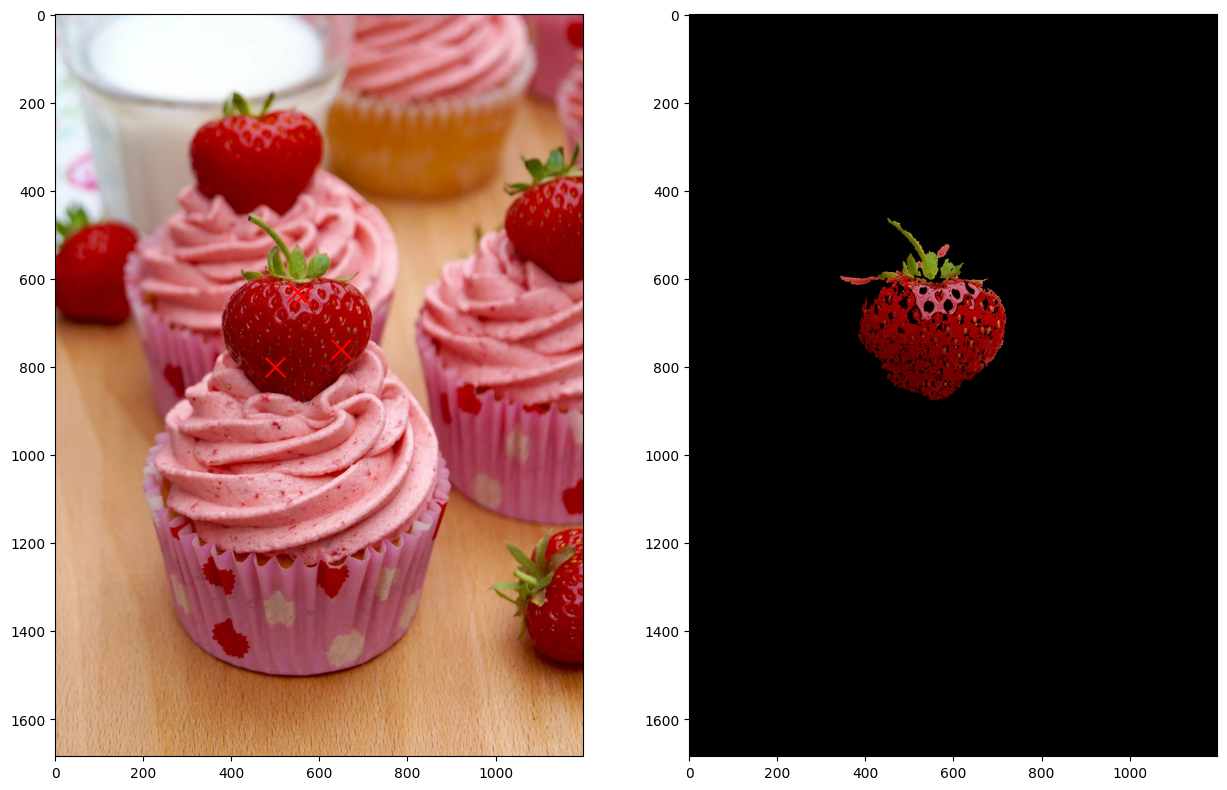

In [5]:
# определяем координаты начальных точек
seeds = [(630,550), (800, 500), (760, 650), (640, 560)]
x = list(map(lambda x: x[1], seeds))
y = list(map(lambda x: x[0], seeds))
# порог похожести цвета региона
threshold = 30
# находим сегментацию используя метод из segmentation_utils
segmented_region = segmentation_utils.region_growingHSV(image_hsv, seeds, threshold)
# накладываем маску - отображаем только участки попавшие в какой-либо сегмент
result = cv2.bitwise_and(img, img, mask=segmented_region)

plt.figure(figsize=(15,20))
plt.subplot(1, 2, 1)
plt.scatter(x, y, marker="x", color="red", s=200)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.show()

Результаты не радуют.
Выделена только одна ягода. Для нее потребовалось 4 точки, и результаты при этом все равно не идеальны. Чтобы выделить все углубления на ягоде, нужно в каждое попасть точкой.
Помимо этого, выделен черенок, хотя он зелёный и его вообще не звали.
Уменьшение порога схожести цвета ухудшает и выделение ягоды. Придется использовать больше точек, чтобы выделить такую же область, как сейчас.

### Метод деления

#### Субъективно оптимальные параметры
Мне кажутся оптимальными параметры: порог похожести цвета = 30, минимальный размер области для деления = 17. Ягоды различимы (можно понять, что их 5 штук), а фон недетализирован. Крем на кексе имеет слишком резкие перепады по цвету - не получается выставить пороги так, чтобы и крем обощался, и ягоды не пропадали

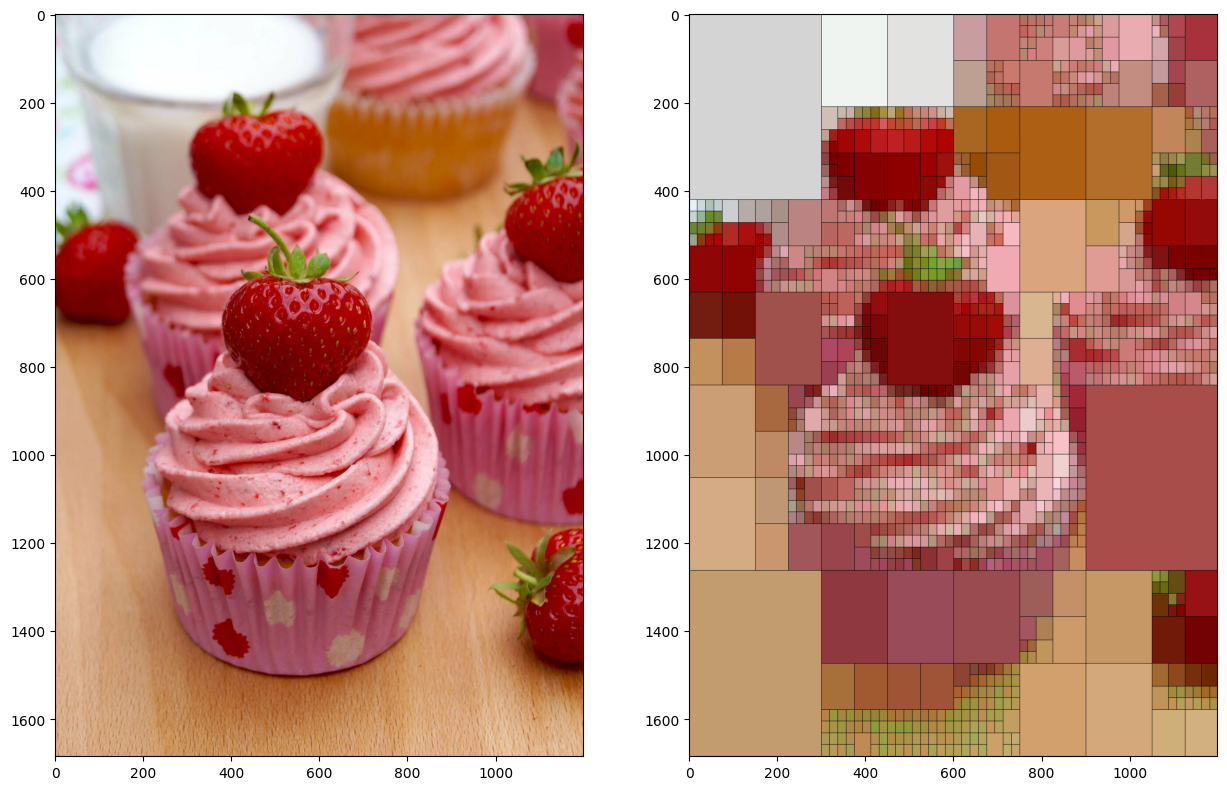

In [22]:
qt = segmentation_utils.QTree(stdThreshold = 30, minPixelSize = 17,img = img.copy())
qt.subdivide()
tree_image = qt.render_img(thickness=1, color=(0,0,0))

plt.figure(figsize=(15,20))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(tree_image, cv2.COLOR_BGR2RGB))
plt.show()

#### Пример порогов с меньшим количеством деталей
Жаль, что, не зная исходное изображение, невозможно угадать, что скрывается за прямоугольниками

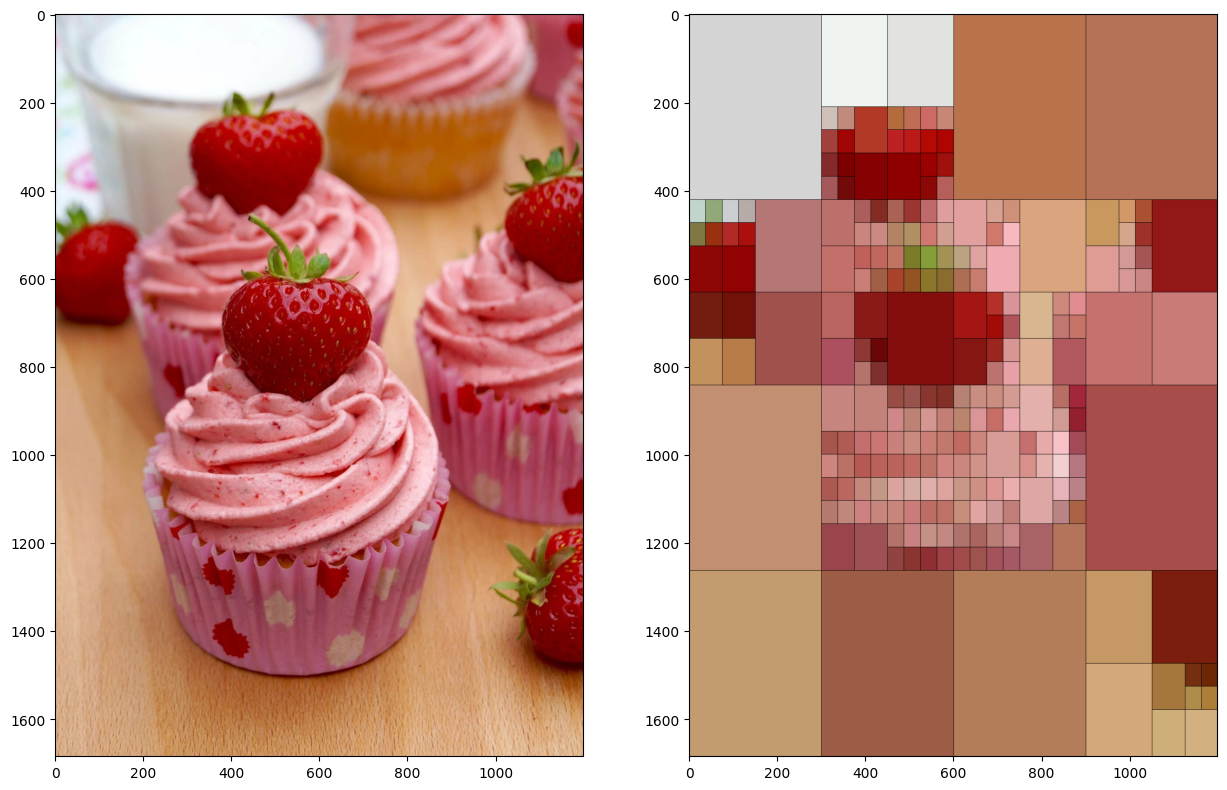

In [25]:
qt = segmentation_utils.QTree(stdThreshold = 50, minPixelSize = 20,img = img.copy())
qt.subdivide()
tree_image = qt.render_img(thickness=1, color=(0,0,0))

plt.figure(figsize=(15,20))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(tree_image, cv2.COLOR_BGR2RGB))
plt.show()

#### Пример с большим количеством деталей
Цвета настолько выделены, что даже зелень от текстуры стола стала явной

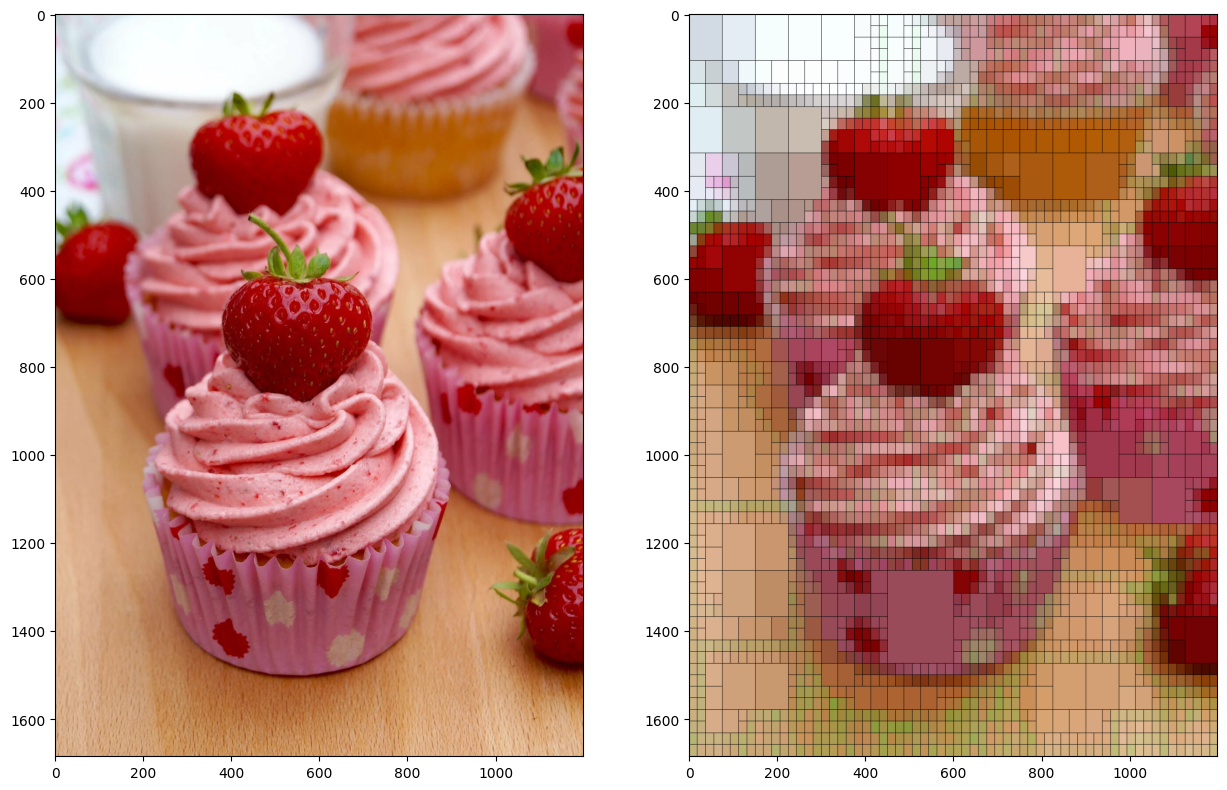

In [26]:
qt = segmentation_utils.QTree(stdThreshold = 5, minPixelSize = 10,img = img.copy())
qt.subdivide()
tree_image = qt.render_img(thickness=1, color=(0,0,0))

plt.figure(figsize=(15,20))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(tree_image, cv2.COLOR_BGR2RGB))
plt.show()

## Метод водораздела

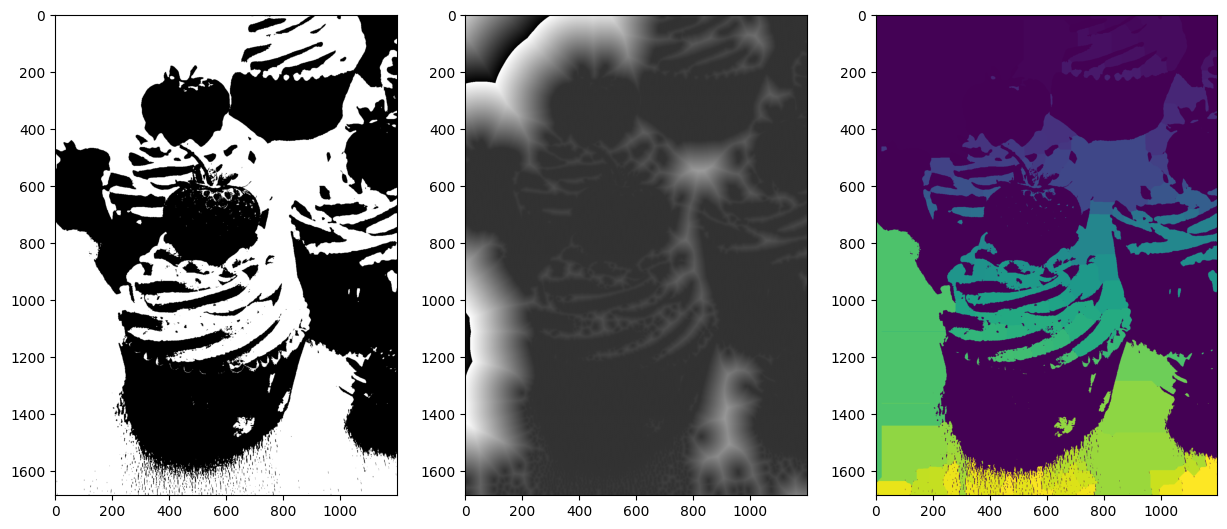

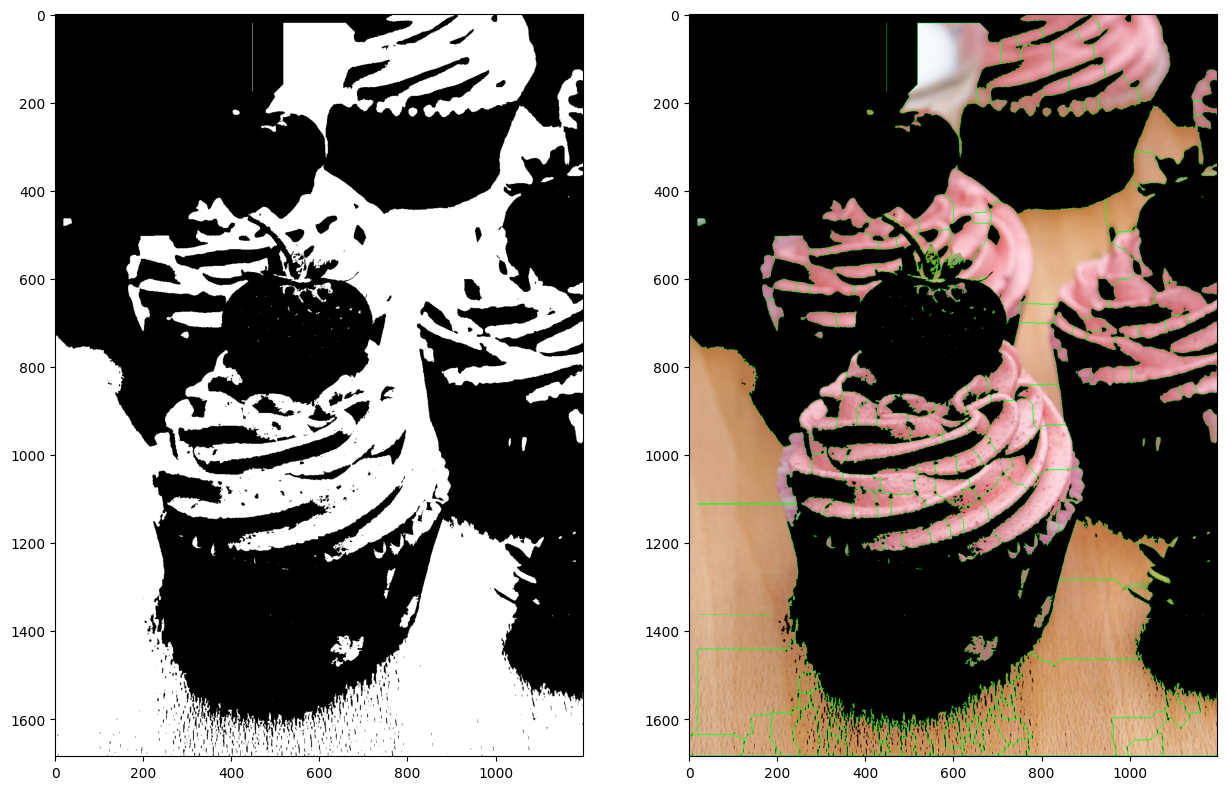

In [43]:
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
binary_image = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
distance_map = ndimage.distance_transform_edt(binary_image)
local_max = peak_local_max(distance_map, min_distance=20, labels=binary_image)

mask_local_max = np.zeros_like(binary_image, dtype=bool)

mask_local_max[tuple(local_max.T)] = True

markers = ndimage.label(mask_local_max, structure=np.ones((3, 3)))[0]
labels = watershed(-distance_map, markers, mask=binary_image)

plt.figure(figsize=(15,20))
plt.subplot(1, 3, 1)
plt.imshow(binary_image, cmap="gray")
plt.subplot(1, 3, 2)
plt.imshow(np.uint8(distance_map + 50), cmap="gray")
plt.subplot(1, 3, 3)
plt.imshow(np.uint8(labels))
plt.show()

mask1 = np.zeros(img.shape[0:2], dtype="uint8")
total_area = 0
for label in np.unique(labels):
    if label < 2:
        continue
    mask = np.zeros(img_gray.shape, dtype="uint8")
    mask[labels == label] = 255
    mask1 = mask1 + mask

    cnts = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = cnts[0] if len(cnts) == 2 else cnts[1]
    c = max(cnts, key=cv2.contourArea)
    area = cv2.contourArea(c)
    total_area += area
    cv2.drawContours(img, [c], -1, (36,255,12), 1)

result = cv2.bitwise_and(img, img, mask=mask1)

plt.figure(figsize=(15,20))
plt.subplot(1, 2, 1)
plt.imshow(mask1, cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.show()

Метод водораздела утверждает, что объект на этом изображении - крем и стол.